## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1**: Bagaimana hubungan antara kandungan makronutrien (protein, lemak, dan karbohidrat) terhadap jumlah kalori pada makanan per 100 gram?
- **Pertanyaan 2**: Bagaimana karakteristik makanan dengan kandungan kalori tertinggi dan terendah berdasarkan komposisi makronutrien (protein, lemak, dan karbohidrat)?
- **Pertanyaan 3**: Bagaimana distribusi makanan berdasarkan kategori kalori (rendah, sedang, tinggi) dan bagaimana perbedaan profil nutrisinya?
- **Pertanyaan 4**: Apa saja 10 makanan/minuman Indonesia dengan nilai tertinggi dan terendah berdasarkan rasio protein terhadap kalori (protein efficiency), serta apa implikasinya bagi konsumen yang ingin membangun massa otot atau menurunkan berat badan?

## Import Packages/Library yang Digunakan
Pada bagian ini, dilakukan import beberapa library yang akan digunakan selama proses analisis. Pandas digunakan untuk mengolah data, numpy untuk perhitungan angka, serta matplotlib dan seaborn untuk membuat visualisasi.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from PIL import Image

## Data Wrangling


### Gathering Data
Pada tahap ini dilakukan proses pengumpulan data (gathering data) dengan mengakses dataset yang tersimpan di Google Drive. File dataset berbentuk csv diakses menggunakan URL. Dataset diperoleh dari Kaggle dengan judul "Indonesian Food and Drink Nutrition Dataset". Dalam dataset tersebut, kandungan dari karbohidrat, protein, lemak, dan kalori masing-masing per 100 gram makanan/minuman.


In [3]:
df = pd.read_csv('data_raw/nutrition.csv')

**Insight:**
- Dataset 'nutrition.csv' berhasil diakses dan dimuat dari folder 'data_raw' tanpa kendala.
- Data telah siap digunakan untuk tahap analisis selanjutnya.

### Assessing Data
Pada tahap ini dilakukan pengecekan data untuk mengetahui kondisi dataset, seperti tipe data, nilai yang hilang, dan gambaran umum data. Hal ini dilakukan agar data siap digunakan untuk proses analisis selanjutnya.

In [4]:
df.head()

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


In [6]:
df.describe()

,id,calories,proteins,fat,carbohydrate
count,1346.000000,1346.000000,1346.000000,1346.000000,1346.000000
mean,673.500000,203.217385,10.001189,7.584027,25.390193
std,388.701042,163.075430,11.847980,13.733063,32.193054
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,337.250000,75.000000,1.800000,0.500000,4.525000
50%,673.500000,146.000000,5.000000,2.000000,13.300000
75%,1009.750000,333.750000,15.000000,8.275000,37.575000
max,1346.000000,940.000000,83.000000,100.000000,647.000000


**Insight:**
1. Dataset tersebut memuat 1346 baris makanan & minuman Indonesia. Setiap baris terdiri dari 7 kolom, yaitu:
   - id: index data
   - calories: jumlah kalori (dalam kal) per 100 gram makanan/minuman
   - proteins: jumlah protein (dalam gram) per 100 gram makanan/minuman
   - fat: jumlah lemak (dalam gram) per 100 gram makanan/minuman
   - carbohydrate: jumlah karbohidrat (dalam gram) per 100 gram makanan/minuman
   - name: nama makanan/minuman
   - image: tautan ke gambar makanan/minuman
2. Tipe data pada kolom 'name' dan 'image' masih berupa Object.

### Cleaning Data
Pada tahap ini dilakukan pembersihan data, seperti mengecek dan menangani missing values, mengecek dan menangani data duplikat, mengatasi outlier, dll.

In [7]:
# Periksa missing value
df.isnull().sum()

id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

In [8]:
# Periksa duplikasi data
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [9]:
# Menghapus kolom 'id' karena hanya berfungsi sebagai penanda urutan data dan tidak memiliki nilai analitis
df = df.drop(columns=['id'])

In [10]:
# Rename kolom
df = df.rename(columns={
    'calories': 'Kalori',
    'proteins': 'Protein',
    'fat': 'Lemak',
    'carbohydrate': 'Karbohidrat',
    'name': 'Nama',
    'image': 'URL Gambar'
})
df.head()

,Kalori,Protein,Lemak,Karbohidrat,Nama,URL Gambar
0,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [11]:
# Mengonversi tipe data Object ke String
df['Nama'] = df['Nama'].astype('string')
df['URL Gambar'] = df['URL Gambar'].astype('string')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Kalori       1346 non-null   float64
 1   Protein      1346 non-null   float64
 2   Lemak        1346 non-null   float64
 3   Karbohidrat  1346 non-null   float64
 4   Nama         1346 non-null   string 
 5   URL Gambar   1346 non-null   string 
dtypes: float64(4), string(2)
memory usage: 63.2 KB


**Insight:**
- Tidak ditemukan adanya missing values dan data duplikat.
- Kolom 'id' dihapus karena hanya berfungsi sebagai penanda urutan data dan tidak memiliki nilai analitis.
- Mengubah nama kolom ke Bahasa Indonesia agar lebih mudah dipahami.
- Tipe data pada kolom 'Nama' dan 'URL Gambar' berhasil diubah dari Object menjadi String.

In [13]:
# Menghitung batas outlier dengan Metode IQR & mengidentifikasi jumlah data outlier
cols = ['Kalori', 'Protein', 'Lemak', 'Karbohidrat']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Batas bawah:", lower)
    print("Batas atas:", upper)

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{len(outliers)} outliers")


Kalori
Batas bawah: -313.125
Batas atas: 721.875
13 outliers

Protein
Batas bawah: -17.999999999999996
Batas atas: 34.8
64 outliers

Lemak
Batas bawah: -11.162500000000001
Batas atas: 19.9375
162 outliers

Karbohidrat
Batas bawah: -45.050000000000004
Batas atas: 87.15
17 outliers


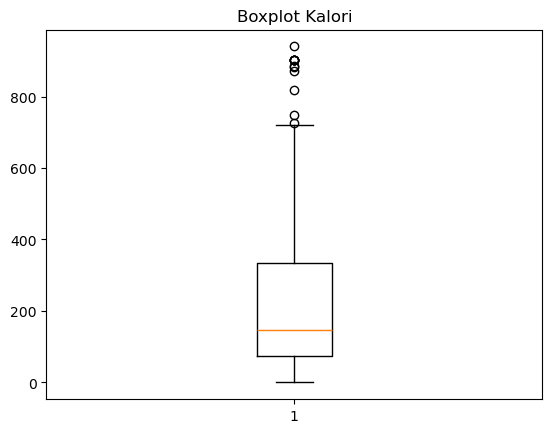

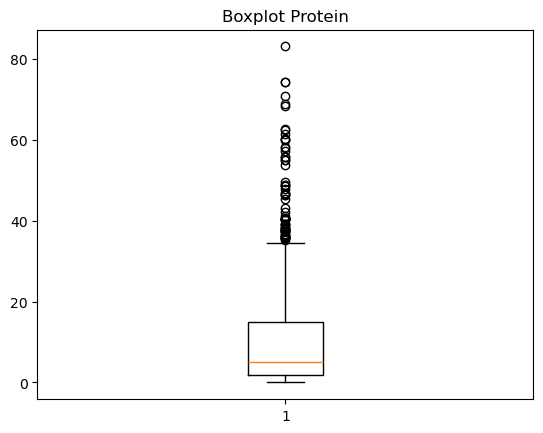

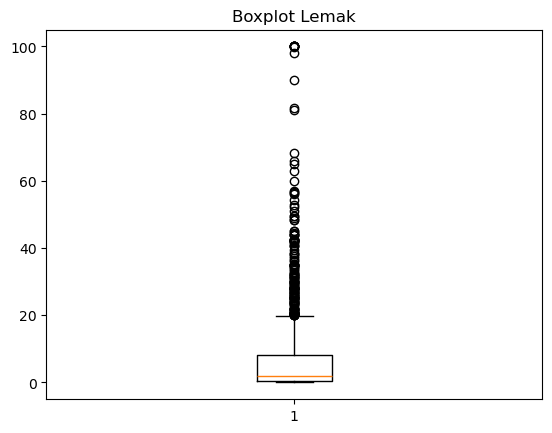

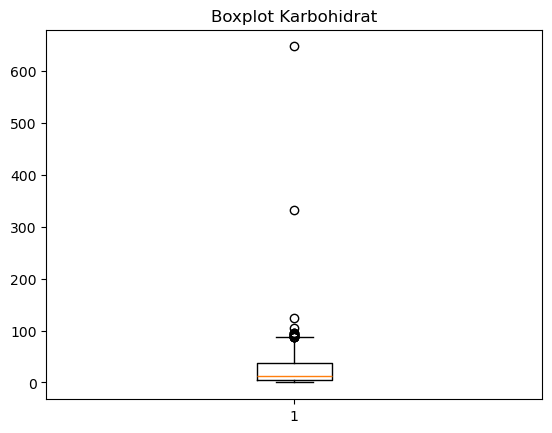

In [14]:
# Visualisasi outlier menggunakan boxplot
for col in cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

**Insight:**
- Variabel lemak memiliki jumlah outlier terbanyak (162 data), menunjukkan bahwa kandungan lemak pada makanan sangat bervariasi dibandingkan nutrisi lainnya.
- Protein memiliki 64 outlier, menunjukkan adanya variasi kandungan protein yang cukup signifikan pada makanan.
- Kalori hanya memiliki 13 outlier, menunjukkan bahwa sebagian besar makanan memiliki distribusi kalori yang relatif stabil.
- Karbohidrat memiliki jumlah outlier yang sedikit (17 data), menunjukkan distribusi yang relatif merata.
- Nilai outlier yang ditemukan kemungkinan besar merupakan representasi nyata dari variasi jenis makanan, bukan kesalahan data.

In [15]:
# Menangani outlier
df_clean = df.copy()

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

df_clean.head()

,Kalori,Protein,Lemak,Karbohidrat,Nama,URL Gambar
2,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...
5,85.0,0.9,6.5,7.7,Alpukat segar,https://katakabar.com/assets/images/upload/new...
6,96.0,3.7,0.6,19.1,Ampas kacang hijau,https://images.tokopedia.net/img/cache/215-squ...


In [16]:
# Perbandingan
print("Sebelum:", df.shape)
print("Sesudah:", df_clean.shape)

Sebelum: (1346, 6)
Sesudah: (1103, 6)


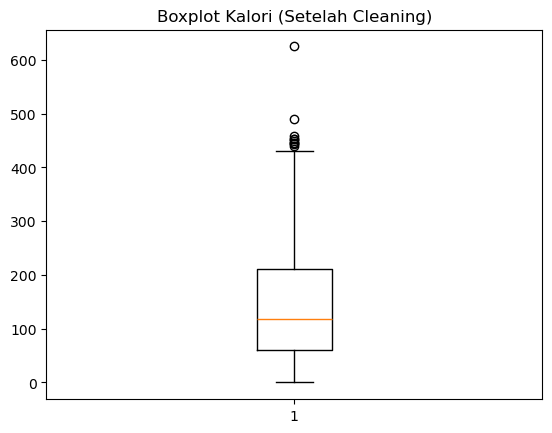

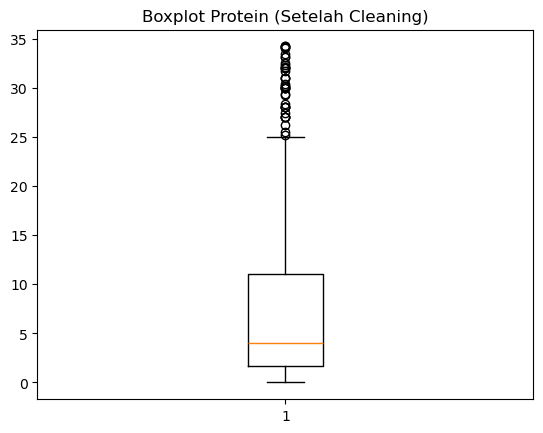

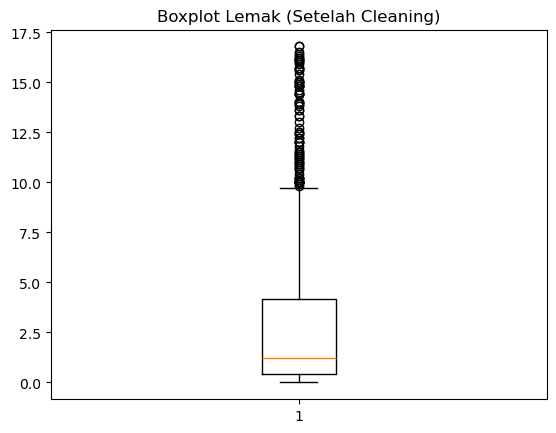

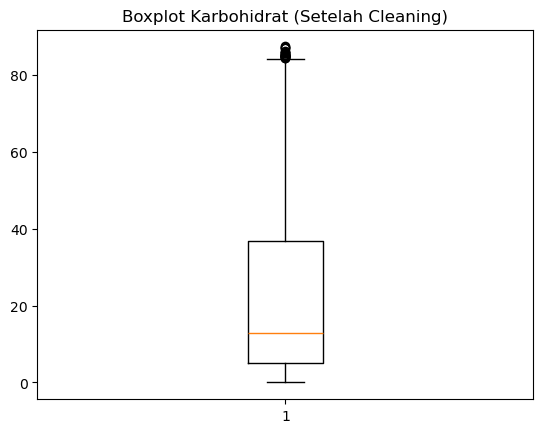

In [17]:
# Visualisasi boxplot setelah cleaning outlier
for col in cols:
    plt.figure()
    plt.boxplot(df_clean[col])
    plt.title(f"Boxplot {col} (Setelah Cleaning)")
    plt.show()

**Insight:**
- Setelah dilakukan penanganan outlier menggunakan metode IQR pada seluruh variabel numerik, jumlah data berkurang dari 1346 menjadi 1103 data. Hal ini menunjukkan bahwa terdapat 243 data yang termasuk dalam kategori outlier.
- Banyaknya data yang dihapus mengindikasikan bahwa variasi nilai nutrisi pada dataset cukup tinggi.
- Setelah dilakukan penanganan outlier, distribusi data menjadi lebih terpusat dan stabil. Variabel lemak tetap menunjukkan variasi paling tinggi dibandingkan variabel lainnya, sementara karbohidrat masih memiliki beberapa nilai tinggi.
- Sisa nilai ekstrem yang masih ada cenderung tidak terisolasi secara jauh, sehingga dapat dianggap sebagai bagian dari variasi alami data makanan, khususnya untuk makanan dengan kandungan nutrisi tinggi.
- Penanganan outlier ini membantu mengurangi pengaruh nilai ekstrem terhadap analisis, meskipun terdapat kemungkinan bahwa beberapa data ekstrem yang valid turut terhapus..

In [18]:
# Analisis Lanjutan
df_clean['Total Nutrisi'] = (
    df_clean['Protein'] +
    df_clean['Lemak'] +
    df_clean['Karbohidrat']
)
df_clean.head()

,Kalori,Protein,Lemak,Karbohidrat,Nama,URL Gambar,Total Nutrisi
2,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0.2
3,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,12.3
4,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,8.7
5,85.0,0.9,6.5,7.7,Alpukat segar,https://katakabar.com/assets/images/upload/new...,15.1
6,96.0,3.7,0.6,19.1,Ampas kacang hijau,https://images.tokopedia.net/img/cache/215-squ...,23.4


In [19]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103 entries, 2 to 1345
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Kalori         1103 non-null   float64
 1   Protein        1103 non-null   float64
 2   Lemak          1103 non-null   float64
 3   Karbohidrat    1103 non-null   float64
 4   Nama           1103 non-null   string 
 5   URL Gambar     1103 non-null   string 
 6   Total Nutrisi  1103 non-null   float64
dtypes: float64(5), string(2)
memory usage: 68.9 KB


**Insight:**
- Penambahan kolom Total Nutrisi hanya sebagai fitur tambahan untuk mengetahui total kandungan makronutrien dalam 100 gram makanan
- Seluruh 1.103 data memiliki nilai Total Nutrisi yang valid (tidak ada missing value).

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data serta memperoleh insight awal terkait distribusi dan hubungan antar variabel dalam dataset.

In [20]:
# Melihat ringkasan statistik dari data yang sudah dibersihkan
df_clean.describe()

,Kalori,Protein,Lemak,Karbohidrat,Total Nutrisi
count,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000
mean,152.936174,7.343427,3.015684,24.497824,34.856936
std,114.807022,7.625309,3.851084,25.730348,26.820850
min,0.000000,0.000000,0.000000,0.000000,0.200000
25%,61.000000,1.700000,0.400000,5.000000,14.650000
50%,119.000000,4.000000,1.200000,13.000000,25.000000
75%,212.000000,11.050000,4.150000,36.750000,45.000000
max,625.000000,34.200000,16.800000,87.400000,98.100000


**Insight:**
- Rata-rata makanan mengandung 152.9 kalori, 7.3g protein, 3g lemak, dan 24.5g karbohidrat per 100 gram.
- Standar deviasi tertinggi ada pada Karbohidrat (25.7) dan Total Nutrisi (26.8), menunjukkan variasi yang besar antar makanan.
- Ada makanan dengan 0 kalori (seperti agar-agar) dan ada yang mencapai 625 kalori per 100 gram.

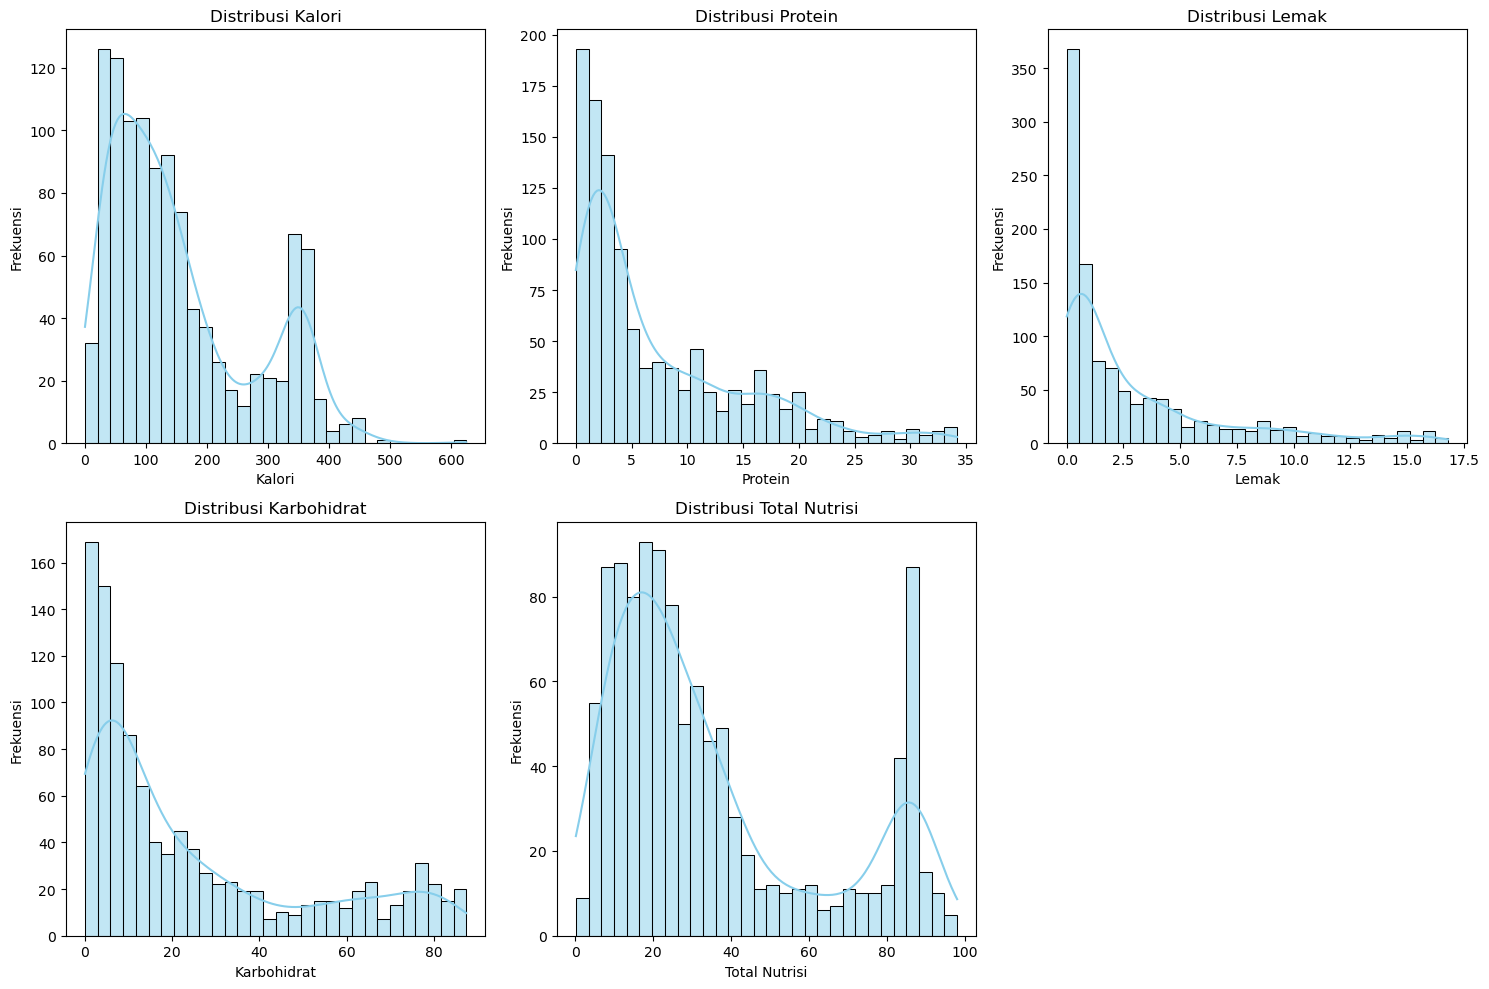

In [21]:
# Visualisasi distribusi data dengan histogram

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['Kalori', 'Protein', 'Lemak', 'Karbohidrat', 'Total Nutrisi']

for i, col in enumerate(cols):
    row = i // 3
    col_pos = i % 3
    sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[row, col_pos], color='skyblue')
    axes[row, col_pos].set_title(f'Distribusi {col}')
    axes[row, col_pos].set_xlabel(col)
    axes[row, col_pos].set_ylabel('Frekuensi')

# Hapus axis kosong
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

**Insight:**
1. Distribusi Kalori

   - Dari histogram terlihat bahwa distribusinya right-skewed dengan ekor panjang
   - Sebagian besar makanan/minuman Indonesia memiliki kalori rendah hingga sedang, terkonsentrasi di rentang 0 - 300 kalori per 100 gram.
   - Frekuensi tertinggi terjadi pada rentang 30 - 150 kalori.
   - Hanya sedikit makanan yang memiliki kalori tinggi (>400 kalori) menunjukkan bahwa mayoritas makanan Indonesia cenderung rendah kalori, yang baik untuk pola makan sehat.
2. Distribusi Protein

   - Dari histogram terlihat bahwa distribusinya right-skewed sangat tajam
   - Kebanyakan makanan memiliki kandungan protein sangat rendah, terkonsentrasi di rentang 0 - 10 gram per 100 gram.
   - Puncak frekuensi tertinggi ada di rentang 0 - 2 gram protein (makanan seperti sayuran, buah, dan karbohidrat sederhana).
   - Jumlah makanan menurun drastis seiring kenaikan kadar protein dan hanya sedikit makanan yang tinggi protein (>20 gram).
3. Distribusi Lemak
   - Dari histogram terlihat bahwa distribusinya right-skewed dengan ekor paling panjang.
   - Mayoritas makanan memiliki lemak sangat rendah, terkonsentrasi di rentang 0 - 5 gram per 100 gram.
   - Puncak tertinggi ada di rentang 0 - 2 gram lemak dan ekornya paling panjang dibanding variabel lain, artinya ada variasi lemak yang sangat lebar.
   - Beberapa makanan memiliki lemak tinggi (10-16 gram).
   - Lemak adalah makronutrien dengan variasi paling ekstrem.
4. Distribusi Karbohidrat
   - Dari histogram terlihat bahwa distribusinya right-skewed dengan sebaran lebih lebar.
   - Puncak frekuensi ada di rentang 0-10 gram, tetapi masih banyak makanan di rentang 20-40 gram.
   - Beberapa makanan sangat tinggi karbohidrat (>60 gram).
   - Karbohidrat memiliki variasi yang lebar, dari yang sangat rendah (<10g) hingga sangat tinggi (>60g) per 100g makanan.
5. Distribusi Total Nutrisi
   - Dari histogram terlihat bahwa distribusi Total Nutrisi hampir simetris dengan sedikit kecenderungan ke kanan (right-skewed).
   - Puncak distribusi berada di rentang 20 - 40 gram total makronutrien per 100 gram makanan, artinya sebagian besar makanan Indonesia memiliki total makronutrien yang cukup seimbang, tidak terlalu rendah dan tidak terlalu tinggi.
   - Sebaran relatif merata dari 0 hingga 80 gram.
   - Histogram menunjukkan gambaran kepadatan makronutrien secara keseluruhan.

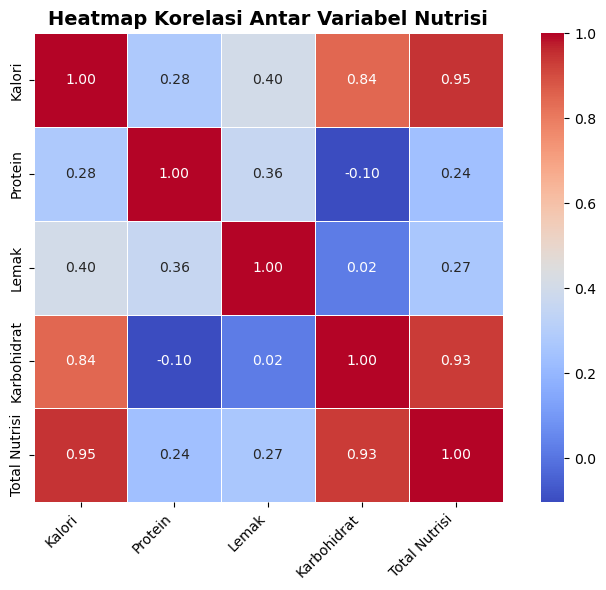

In [22]:
# Heatmap korelasi

# Menyiapkan kolom numerik untuk korelasi
kolom_korelasi = ['Kalori', 'Protein', 'Lemak', 'Karbohidrat', 'Total Nutrisi']

# Menghitung matriks korelasi
corr_matrix = df_clean[kolom_korelasi].corr()

# Membuat heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Antar Variabel Nutrisi', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
1. Korelasi Kuat (r > 0.7)
   - Kalori vs Total Nutrisi (0.95): korelasi kuat karena Total Nutrisi merupakan akumulasi dari komponen gizi.
   - Total Nutrisi vs Karbohidrat (0.93): Karbohidrat mendominasi komposisi Total Nutrisi.
   - Kalori vs Karbohidrat (0.84): Karbohidrat merupakan penyumbang kalori terbesar.
2. Korelasi Sedang (0.3 < r < 0.7)
   - Kalori vs Lemak (0.40): Lemak cukup berpengaruh terhadap kalori.
   - Protein vs Lemak (0.36): Ada hubungan positif lemah antara protein dan lemak.
3. Korelasi Lemah (r < 0.3)
   - Protein vs Kalori (0.28): Protein hampir tidak memengaruhi kalori.
   - Protein vs Total Nutrisi (0.24): Kontribusi protein terhadap total nutrisi kecil.
   - Lemak vs Karbohidrat (0.02): Hampir tidak ada hubungan.
   - Protein vs Karbohidrat (-0.10): Korelasi negatif sangat lemah (tidak signifikan).

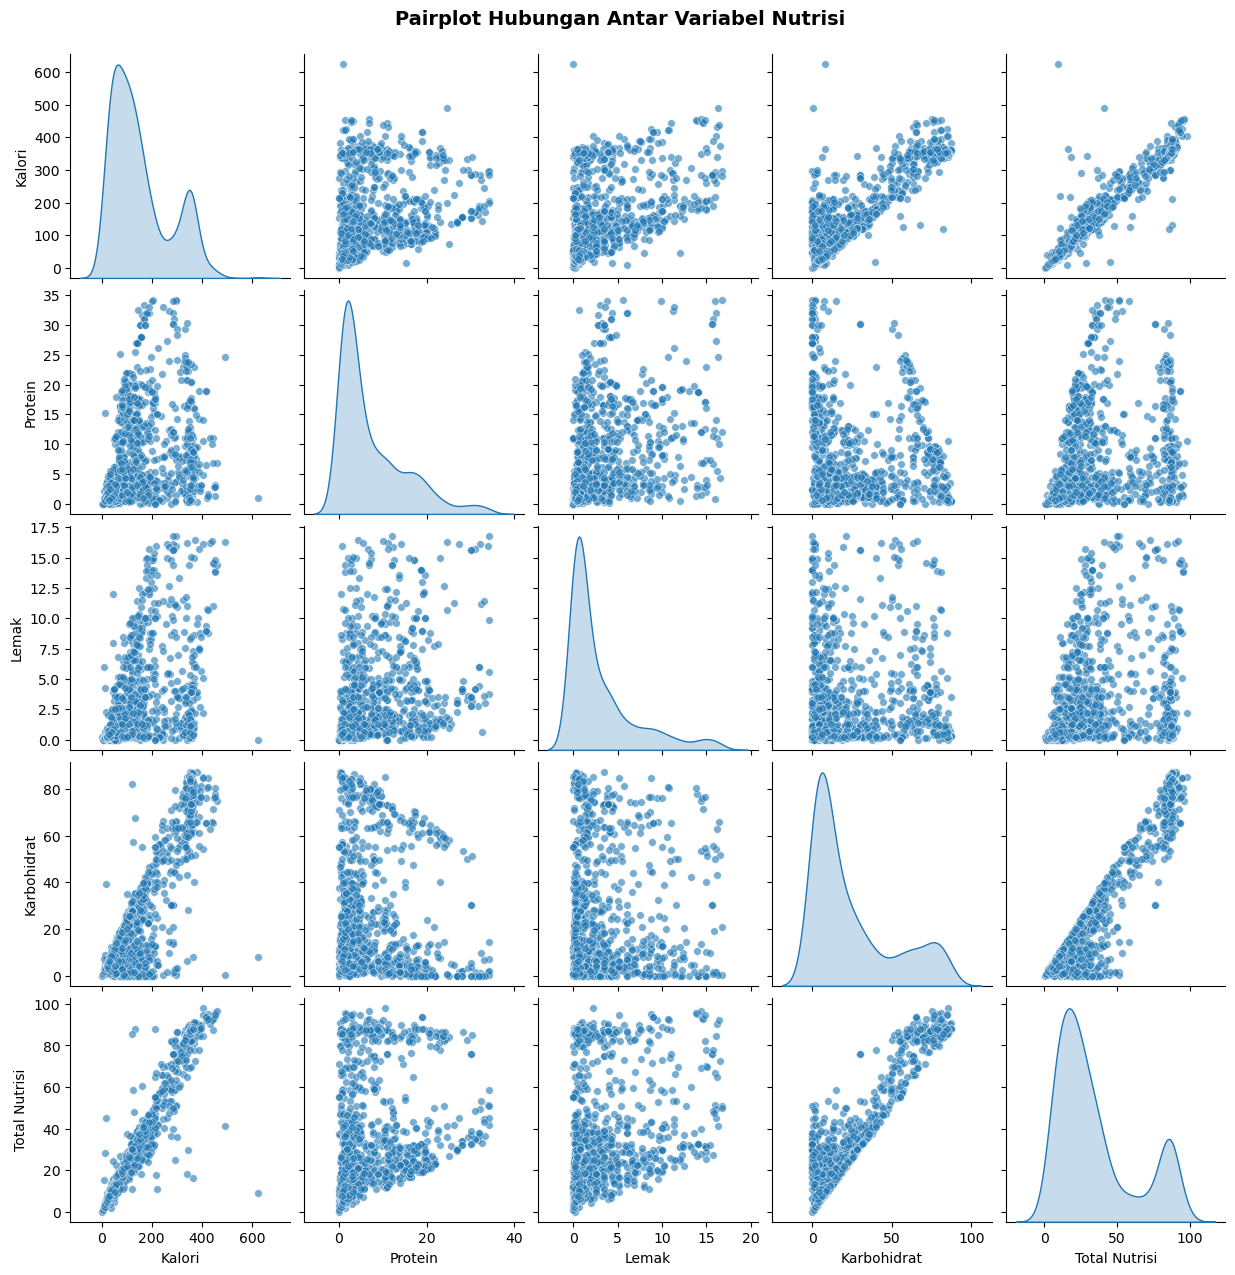

In [23]:
# Membuat pairplot untuk melihat hubungan antar variabel secara visual

sns.pairplot(df_clean[kolom_korelasi],
             diag_kind='kde',  # distribusi pakai KDE (lebih halus)
             plot_kws={'alpha': 0.6, 's': 30})  # 's' untuk ukuran titik
plt.suptitle('Pairplot Hubungan Antar Variabel Nutrisi', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Insight:**
1. Hubungan dengan Kalori
   - Pairplot antara Kalori dengan Total Nutrisi menunjukkan titik paling rapat (hubungan paling kuat).
   - Pairplot dengan Karbohidrat  menunjukkan titik cukup rapat (hubungan kuat).
   - Pairplot dengan Lemak  menunjukkan titik yang menyebar (hubungan sedang).
   - Pairplot dengan Protein  menunjukkan titik yang sangat menyebar (hubungan lemah).
2. Hubungan Antar Makronutrien
   - Pairplot antara Karbohidrat dengan Protein menunjukkan titik yang acak (tidak berhubungan).
   - Pairplot antara Karbohidrat dengan Lemak juga menunjukkan titik yang acak (tidak berhubungan).
   - Pairplot antara Protein dengan Lemak menunjukkan titik yang cenderung mengelompok di area rendah.
3. Hubungan Total Nutrisi
   - Pairplot antara Total Nutrisi dengan Karbohidrat menunjukkan titik yang sangat rapat dan hampir sama.
   - Pairplot dengan Lemak menunjukkan titik yang menyebar.
   - Pairplot dengan Protein menunjukkan titik yang menyebar.
   - Pairplot antara Total Nutrisi dengan Kalori menunjukkan titik paling rapat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana hubungan antara kandungan makronutrien (protein, lemak, dan karbohidrat) terhadap jumlah kalori pada makanan per 100 gram?

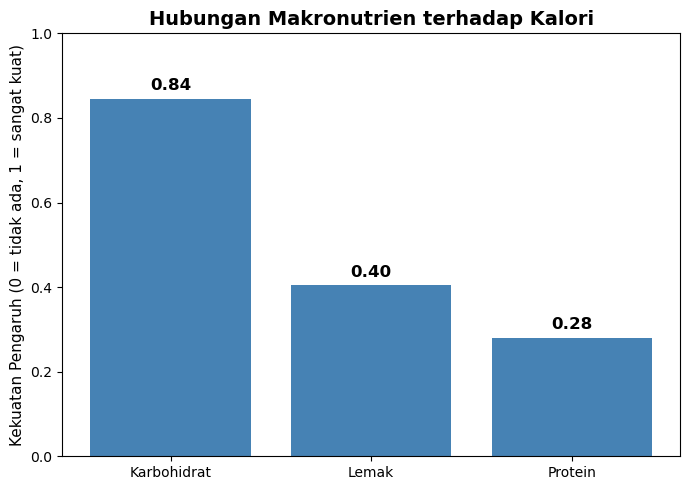

In [24]:
# Visualisasi menggunakan  Bar Chart

# Mengambil nilai korelasi Kalori dengan Protein, Lemak, dan Karbohidrat
korelasi_makronutrien = corr_matrix.loc['Kalori', ['Protein', 'Lemak', 'Karbohidrat']]

# Mengurutkan dari tertinggi ke terendah
korelasi_makronutrien = korelasi_makronutrien.sort_values(ascending=False)

plt.figure(figsize=(7, 5))
bars = plt.bar(korelasi_makronutrien.index, korelasi_makronutrien.values, color='steelblue')

plt.title('Hubungan Makronutrien terhadap Kalori',
          fontsize=14, fontweight='bold')
plt.ylabel('Kekuatan Pengaruh (0 = tidak ada, 1 = sangat kuat)', fontsize=11)
plt.ylim(0, 1)

for bar, val in zip(bars, korelasi_makronutrien.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Karbohidrat memiliki pengaruh paling kuat terhadap jumlah kalori dengan nilai korelasi 0.84. Ini berarti semakin tinggi kandungan karbohidrat dalam suatu makanan, cenderung semakin tinggi pula kalorinya.
- Lemak memiliki pengaruh sedang terhadap kalori dengan nilai korelasi 0.40. Meskipun tidak sekuat karbohidrat, lemak tetap berkontribusi dalam peningkatan kalori.
- Protein memiliki pengaruh paling lemah terhadap kalori dengan nilai korelasi 0.28. Hal ini menunjukkan bahwa variasi kandungan protein dalam data tidak terlalu memengaruhi perbedaan jumlah kalori dibandingkan makronutrien lainnya.
- Jika seseorang ingin mengurangi asupan kalori, prioritas utama adalah mengurangi makanan tinggi karbohidrat, diikuti oleh makanan tinggi lemak, sementara pengaruh protein relatif lebih kecil.
- Makanan tinggi protein seperti tahu, tempe, ikan, atau daging tanpa lemak dapat menjadi pilihan yang lebih baik dalam pengaturan pola makan, karena cenderung memberikan kontribusi kalori yang lebih terkendali dibandingkan makanan tinggi karbohidrat atau lemak.

### Pertanyaan 2: Bagaimana karakteristik makanan dengan kandungan kalori tertinggi dan terendah berdasarkan komposisi makronutrien (protein, lemak, dan karbohidrat)?

=== Statistik Total Nutrisi ===
Q1 (25% terbawah): 14.7 gram
Q3 (25% teratas): 45.0 gram
Rentang data: 0.2 - 98.1 gram


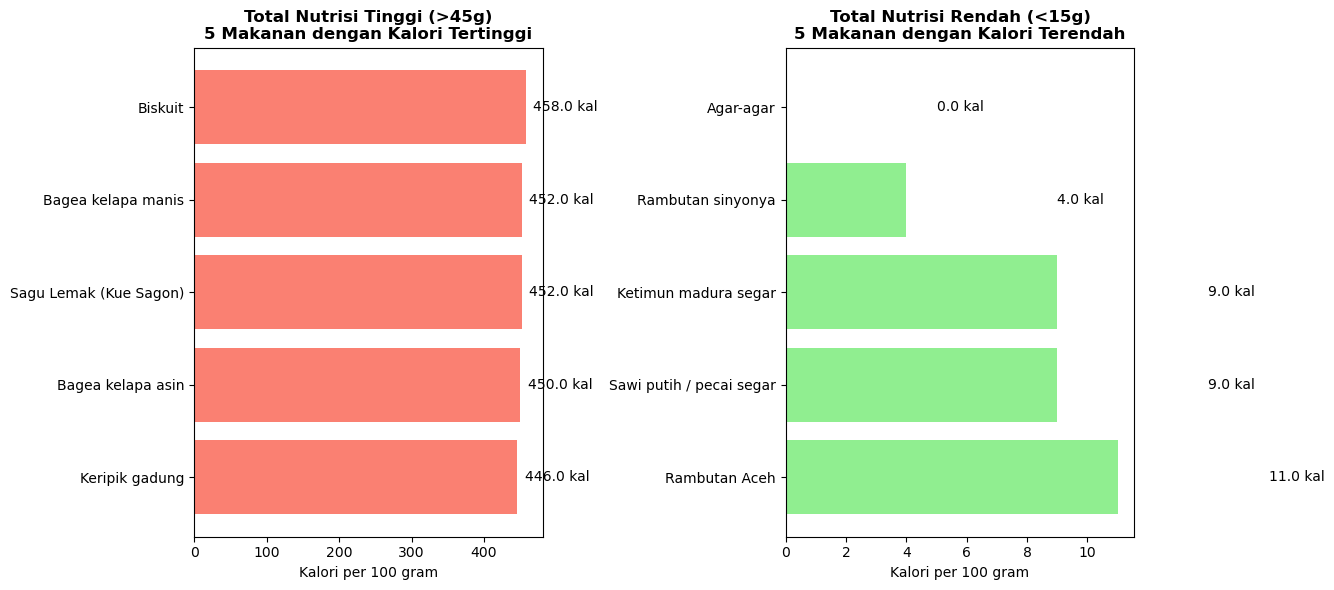


TOTAL NUTRISI TINGGI (>45g) - Kalori Tertinggi:


,Nama,Total Nutrisi,Kalori,Karbohidrat,Lemak,Protein
147,Biskuit,96.4,458.0,75.1,14.4,6.9
56,Bagea kelapa manis,95.7,452.0,80.6,13.8,1.3
1063,Sagu Lemak (Kue Sagon),94.4,452.0,76.8,14.8,2.8
55,Bagea kelapa asin,95.2,450.0,78.1,13.9,3.2
724,Keripik gadung,93.3,446.0,76.0,14.5,2.8



TOTAL NUTRISI RENDAH (<15g) - Kalori Terendah:


,Nama,Total Nutrisi,Kalori,Karbohidrat,Lemak,Protein
2,Agar-agar,0.2,0.0,0.0,0.2,0.0
1032,Rambutan sinyonya,0.9,4.0,0.9,0.0,0.0
761,Ketimun madura segar,2.5,9.0,1.9,0.1,0.5
1105,Sawi putih / pecai segar,2.8,9.0,1.7,0.1,1.0
1030,Rambutan Aceh,2.7,11.0,2.7,0.0,0.0


In [25]:
# Menghitung Q1 dan Q3 dari Total Nutrisi
Q1 = df_clean['Total Nutrisi'].quantile(0.25)
Q3 = df_clean['Total Nutrisi'].quantile(0.75)

print(f"=== Statistik Total Nutrisi ===")
print(f"Q1 (25% terbawah): {Q1:.1f} gram")
print(f"Q3 (25% teratas): {Q3:.1f} gram")
print(f"Rentang data: {df_clean['Total Nutrisi'].min():.1f} - {df_clean['Total Nutrisi'].max():.1f} gram")

# Filter data berdasarkan kuartil
total_nutrisi_rendah = df_clean[df_clean['Total Nutrisi'] <= Q1]
total_nutrisi_tinggi = df_clean[df_clean['Total Nutrisi'] >= Q3]

# Mencari 5 makanan dengan kalori tertinggi di kelompok Total Nutrisi Tinggi
tertinggi = total_nutrisi_tinggi.nlargest(5, 'Kalori')[['Nama', 'Total Nutrisi', 'Kalori', 'Karbohidrat', 'Lemak', 'Protein']]

# Mencari 5 makanan dengan kalori terendah di kelompok Total Nutrisi Rendah
terendah = total_nutrisi_rendah.nsmallest(5, 'Kalori')[['Nama', 'Total Nutrisi', 'Kalori', 'Karbohidrat', 'Lemak', 'Protein']]

# Visualisasi menggunakan Bar Chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Kalori Tertinggi (dari kelompok Total Nutrisi Tinggi)
axes[0].barh(tertinggi['Nama'], tertinggi['Kalori'], color='salmon')
axes[0].set_title(f'Total Nutrisi Tinggi (>{Q3:.0f}g)\n5 Makanan dengan Kalori Tertinggi',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Kalori per 100 gram')
axes[0].invert_yaxis()
for i, v in enumerate(tertinggi['Kalori']):
    axes[0].text(v + 10, i, f'{v} kal', va='center')

# Plot Kalori Terendah (dari kelompok Total Nutrisi Rendah)
axes[1].barh(terendah['Nama'], terendah['Kalori'], color='lightgreen')
axes[1].set_title(f'Total Nutrisi Rendah (<{Q1:.0f}g)\n5 Makanan dengan Kalori Terendah',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Kalori per 100 gram')
axes[1].invert_yaxis()
for i, v in enumerate(terendah['Kalori']):
    axes[1].text(v + 5, i, f'{v} kal', va='center')

plt.tight_layout()
plt.show()

print(f"\nTOTAL NUTRISI TINGGI (>{Q3:.0f}g) - Kalori Tertinggi:")
display(tertinggi)

print(f"\nTOTAL NUTRISI RENDAH (<{Q1:.0f}g) - Kalori Terendah:")
display(terendah)

=== Rata-rata Komposisi Nutrisi ===

Kelompok Total Nutrisi Tinggi:


Protein         8.999281
Lemak           4.405396
Karbohidrat    63.048201
dtype: float64


Kelompok Total Nutrisi Rendah:


Protein        2.464130
Lemak          0.896014
Karbohidrat    6.024638
dtype: float64

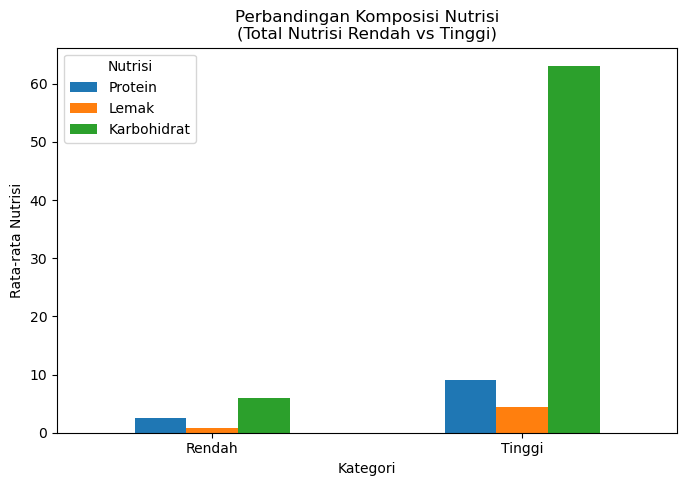

In [26]:
# Analisis komposisi nutrisi
print("=== Rata-rata Komposisi Nutrisi ===")

print("\nKelompok Total Nutrisi Tinggi:")
display(total_nutrisi_tinggi[['Protein','Lemak','Karbohidrat']].mean())

print("\nKelompok Total Nutrisi Rendah:")
display(total_nutrisi_rendah[['Protein','Lemak','Karbohidrat']].mean())

komposisi = pd.DataFrame({
    'Rendah': total_nutrisi_rendah[['Protein','Lemak','Karbohidrat']].mean(),
    'Tinggi': total_nutrisi_tinggi[['Protein','Lemak','Karbohidrat']].mean()
})

komposisi.T.plot(kind='bar', figsize=(8,5))
plt.title('Perbandingan Komposisi Nutrisi\n(Total Nutrisi Rendah vs Tinggi)')
plt.xlabel('Kategori')
plt.ylabel('Rata-rata Nutrisi')
plt.xticks(rotation=0)
plt.legend(title='Nutrisi')
plt.show()

**Insight:**

**Makanan dengan Total Nutrisi Tinggi**

Karakteristik:
- Kalori sangat tinggi yang berkisar antara 446 - 458 kalori per 100 gram.
- Didominasi oleh makanan olahan seperti biskuit, bagea (kue kering), sagu olahan, dan keripik.
- Berdasarkan komposisi nutrisi, kelompok ini sangat didominasi oleh karbohidrat dengan rata-rata sekitar 63 gram, jauh lebih tinggi dibandingkan protein (sekitar 9 gram) dan lemak (sekitar 4 gram).
- Hal ini menunjukkan bahwa karbohidrat menjadi kontributor utama terhadap tingginya kalori, diperkuat dengan tambahan lemak dalam jumlah sedang.
- Protein relatif rendah, sehingga makanan dalam kategori ini cenderung tinggi energi namun kurang optimal untuk kebutuhan pembentukan massa otot.


**Makanan dengan Total Nutrisi Rendah**

Karakteristik:
- Kalori sangat rendah yang berkisar antara 0 - 11 kalori per 100 gram.
- Didominasi oleh makanan alami berair seperti agar-agar, rambutan, ketimun, dan sawi.
- Komposisi nutrisi menunjukkan bahwa seluruh makronutrien berada pada tingkat yang sangat rendah, dengan rata-rata karbohidrat sekitar 6 gram, protein sekitar 2 gram, dan lemak <1 gram.
- Rendahnya seluruh komponen nutrisi ini menyebabkan kontribusi energi (kalori) menjadi sangat kecil.
- Makanan dalam kategori ini lebih cocok untuk konsumsi rendah kalori, seperti dalam program penurunan berat badan.

### Pertanyaan 3: Bagaimana distribusi makanan berdasarkan kategori kalori (rendah, sedang, tinggi) dan bagaimana perbedaan profil nutrisinya?

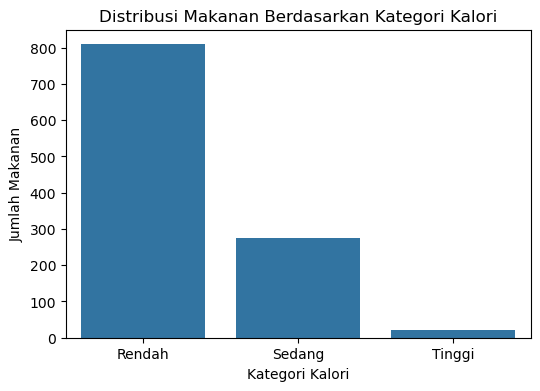


Rata-rata Nutrisi per Kategori:


,Protein,Lemak,Karbohidrat
Kategori Kalori,,,
Rendah,6.506428,2.278245,12.158714
Sedang,9.768978,4.584672,57.835401
Tinggi,7.970000,11.350000,66.890000


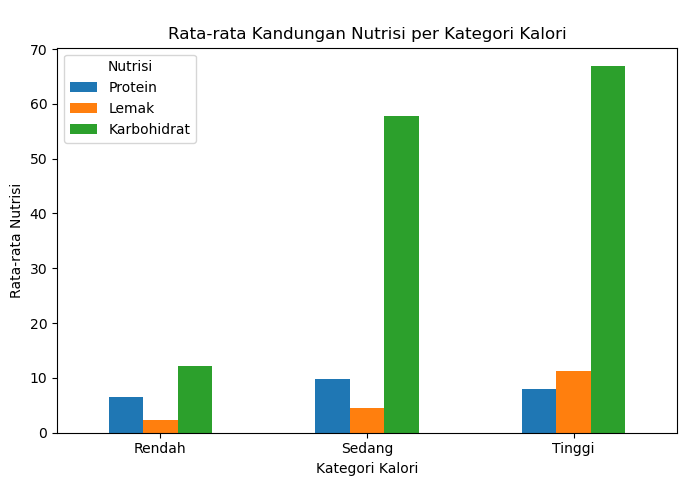

In [27]:
# Membuat fungsi untuk mengelompokkan kalori ke dalam 3 kategori
def kategori_kalori(kalori):
    if kalori < 200:
        return 'Rendah'
    elif kalori <= 400:
        return 'Sedang'
    else:
        return 'Tinggi'

# Menerapkan fungsi ke kolom Kalori
df_clean['Kategori Kalori'] = df_clean['Kalori'].apply(kategori_kalori)

# Mengurutkan kategori dari rendah, sedang, hingga tinggi
df_clean['Kategori Kalori'] = pd.Categorical(
    df_clean['Kategori Kalori'],
    categories=['Rendah', 'Sedang', 'Tinggi'],
    ordered=True
)

# Membuat grafik jumlah makanan di tiap kategori kalori
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='Kategori Kalori')
plt.title('Distribusi Makanan Berdasarkan Kategori Kalori')
plt.xlabel('Kategori Kalori')
plt.ylabel('Jumlah Makanan')

plt.show()

# Mengelompokkan data berdasarkan kategori kalori
# lalu menghitung rata-rata Protein, Lemak, dan Karbohidrat
rata_nutrisi = df_clean.groupby('Kategori Kalori', observed=True)[['Protein', 'Lemak', 'Karbohidrat']].mean()

print("\nRata-rata Nutrisi per Kategori:")
display(rata_nutrisi)

# Membuat bar chart untuk membandingkan rata-rata nutrisi tiap kategori
rata_nutrisi.plot(kind='bar', figsize=(8,5))
plt.title('\nRata-rata Kandungan Nutrisi per Kategori Kalori')
plt.xlabel('Kategori Kalori')
plt.ylabel('Rata-rata Nutrisi')
plt.xticks(rotation=0)
plt.legend(title='Nutrisi')

plt.show()

**Insight:**

**Distribusi Makanan Berdasarkan Kategori Kalori**
- Sebagian besar makanan berada pada kategori kalori rendah (±800 data), diikuti oleh kategori sedang (±270 data), dan hanya sedikit pada kategori tinggi.
- Hal ini menunjukkan bahwa dataset didominasi oleh makanan dengan kandungan energi rendah, seperti buah dan sayuran.

**Perbedaan Profil Nutrisi**
1. Karbohidrat sebagai Faktor Utama
   - Terjadi peningkatan yang sangat signifikan pada karbohidrat, yaitu pada kategori Rendah sekitar 12 gram, kategori Sedang sekitar 58 gram, dan kategori Tinggi sekitar 67 gram.
   - Hal ini menunjukkan bahwa karbohidrat adalah faktor utama yang membedakan kategori kalori.

2. Lemak Meningkat Seiring Kalori
   - Lemak juga meningkat cukup signifikan, yaitu pada kategori Rendah sekitar 2.3 gram, kategori Sedang sekitar 4.6 gram, dan kategori Tinggi sekitar 11.3 gram.
   - Pada kategori tinggi, lemak menjadi kontributor tambahan penting terhadap kalori.

3. Protein Relatif Stabil
   - Protein tidak meningkat secara signifikan, yaitu pada kategori Rendah sekitar 6.5 gram, kategori Sedang sekitar 9.8 gram, dan kategori Tinggi sekitar 8 gram.
   - Hal ini menunjukkan bahwa protein bukan faktor utama penentu tinggi rendahnya kalori.

### Pertanyaan 4: Apa saja 10 makanan/minuman Indonesia dengan nilai tertinggi dan terendah berdasarkan rasio protein terhadap kalori (protein efficiency), serta apa implikasinya bagi konsumen yang ingin membangun massa otot atau menurunkan berat badan?

In [28]:
df_clean['Rasio Protein/Kalori'] = df_clean.apply(
    lambda row: row['Protein'] / row['Kalori'] if row['Kalori'] != 0 else 0, axis=1)

# Menemukan 10 makanan dengan Rasio Protein/Kalori tertinggi
top_protein_efficiency = df_clean.nlargest(10, 'Rasio Protein/Kalori')

# Menemukan 10 makanan dengan Rasio Protein/Kalori terendah
# Menyaring item yang Rasio Protein/Kalori-nya adalah 0 (untuk menghindari nilai 'terendah' ​​yang tidak bermakna dari makanan 0 kalori)
bottom_protein_efficiency = df_clean[df_clean['Rasio Protein/Kalori'] > 0].nsmallest(10, 'Rasio Protein/Kalori')

print("10 Makanan dengan Efisiensi Protein Tertinggi:")
display(top_protein_efficiency[['Nama', 'Protein', 'Kalori', 'Rasio Protein/Kalori']])

print("\n10 Makanan dengan Efisiensi Protein Terendah (selain 0 kalori):")
display(bottom_protein_efficiency[['Nama', 'Protein', 'Kalori', 'Rasio Protein/Kalori']])

10 Makanan dengan Efisiensi Protein Tertinggi:


,Nama,Protein,Kalori,Rasio Protein/Kalori
582,Jukku pallu kaloa masakan,15.2,15.0,1.013333
449,Ikan Gabus segar,25.2,74.0,0.340541
717,Kerang,18.0,59.0,0.305085
720,Kerbau daging segar,18.7,79.0,0.236709
933,Olah-olah,2.1,9.0,0.233333
1326,Udang segar,21.0,91.0,0.230769
814,Kura-kura,19.1,83.0,0.230120
466,Ikan lehoma segar,20.4,90.0,0.226667
519,Ikan Teri Nasi kering,32.5,144.0,0.225694
685,Katak,16.4,73.0,0.224658



10 Makanan dengan Efisiensi Protein Terendah (selain 0 kalori):


,Nama,Protein,Kalori,Rasio Protein/Kalori
60,Bagea kw 2,0.3,382.0,0.000785
1259,Tepung Kentang,0.3,347.0,0.000865
858,Maizena tepung,0.3,341.0,0.000880
857,Madu,0.3,294.0,0.001020
900,Mie Sagu,0.2,190.0,0.001053
327,Dodol galamai,0.4,348.0,0.001149
175,Bubur sagu,0.2,167.0,0.001198
965,Pati Singkong (tapioka),0.5,362.0,0.001381
1066,Sagu singkong kering,0.5,362.0,0.001381
139,Bihun Jagung mentah,0.5,354.0,0.001412


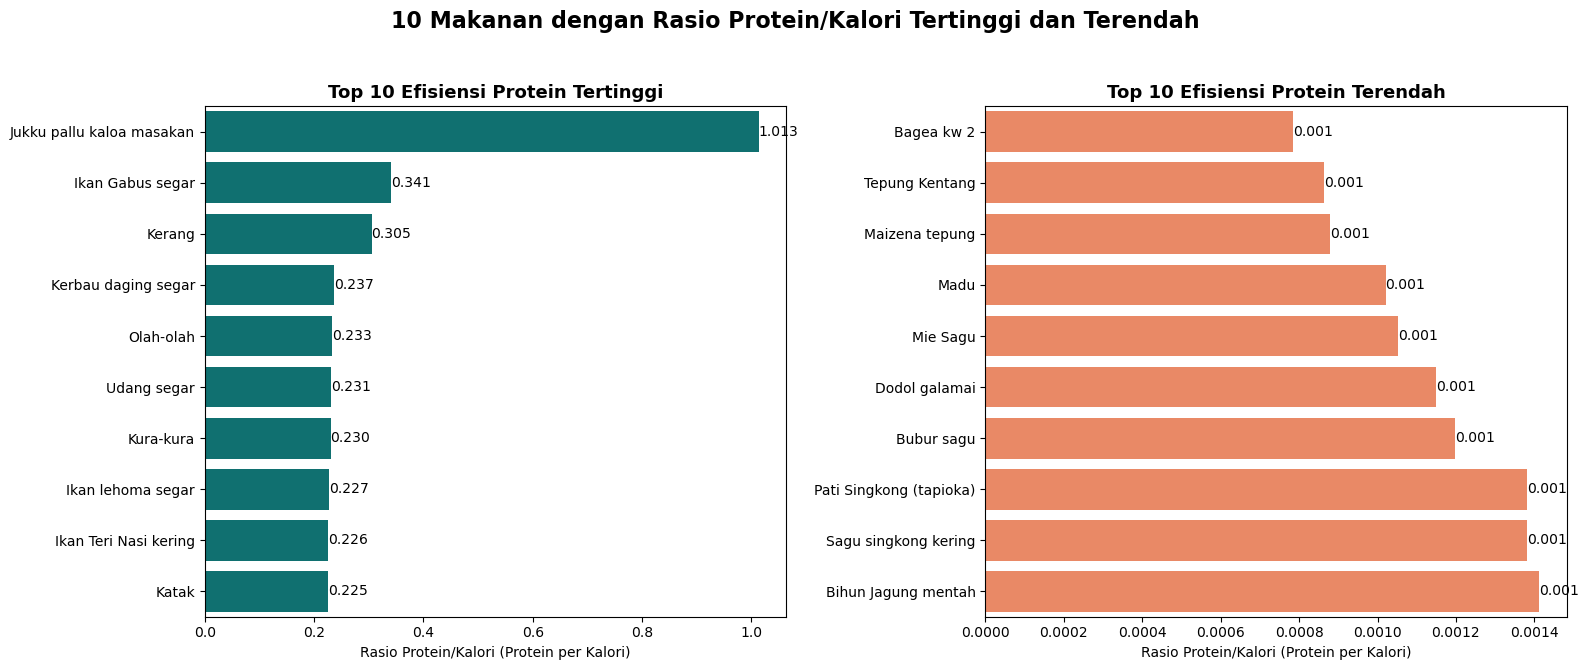

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('10 Makanan dengan Rasio Protein/Kalori Tertinggi dan Terendah', fontsize=16, fontweight='bold')

# Bar Chart Efisiensi Protein Tertinggi
sns.barplot(x='Rasio Protein/Kalori', y='Nama', data=top_protein_efficiency, ax=axes[0], color='teal', legend=False)
axes[0].set_title('Top 10 Efisiensi Protein Tertinggi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rasio Protein/Kalori (Protein per Kalori)')
axes[0].set_ylabel('')
for index, value in enumerate(top_protein_efficiency['Rasio Protein/Kalori']):
    axes[0].text(value, index, f'{value:.3f}', va='center')

# Bar Chart Efisiensi Protein Terendah
sns.barplot(x='Rasio Protein/Kalori', y='Nama', data=bottom_protein_efficiency, ax=axes[1], color='coral', legend=False)
axes[1].set_title('Top 10 Efisiensi Protein Terendah', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rasio Protein/Kalori (Protein per Kalori)')
axes[1].set_ylabel('')
for index, value in enumerate(bottom_protein_efficiency['Rasio Protein/Kalori']):
    axes[1].text(value, index, f'{value:.3f}', va='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Insight:**

**1. Makanan dengan Efisiensi Protein Tertinggi:**

**Karakteristik:** Makanan ini memiliki rasio protein yang sangat tinggi per kalorinya, artinya Anda mendapatkan banyak protein dengan jumlah kalori yang relatif sedikit. Contohnya adalah makanan laut seperti ikan, udang, serta produk protein hewani murni atau makanan dengan sedikit makronutrien lain (lemak/karbohidrat).
- **Implikasi untuk Membangun Massa Otot:** Sangat cocok untuk individu yang ingin membangun massa otot, karena protein adalah blok bangunan otot. Konsumen dapat mengonsumsi makanan ini dalam jumlah yang cukup untuk memenuhi kebutuhan protein tanpa asupan kalori berlebih.
- **Implikasi untuk Menurunkan Berat Badan:** Ideal untuk diet penurunan berat badan. Kandungan protein tinggi membantu meningkatkan rasa kenyang (satiety), mengurangi keinginan untuk makan berlebihan, dan membantu mempertahankan massa otot selama defisit kalori.

**2. Makanan dengan Efisiensi Protein Terendah:**

**Karakteristik:** Makanan ini memiliki rasio protein yang sangat rendah per kalorinya, yang berarti Anda mendapatkan banyak kalori untuk sedikit protein. Makanan ini cenderung kaya karbohidrat atau lemak dan rendah protein. Contohnya adalah makanan olahan manis, minuman bergula, atau beberapa jenis buah dan sayuran yang tinggi karbohidrat alami.
- **Implikasi untuk Membangun Massa Otot:** Kurang efektif. Untuk mendapatkan protein yang cukup dari makanan ini, seseorang harus mengonsumsi dalam jumlah yang sangat besar, yang akan menyebabkan asupan kalori yang sangat tinggi dan tidak efisien untuk pertumbuhan otot.
- **Implikasi untuk Menurunkan Berat Badan:** Tidak disarankan. Makanan ini akan cepat meningkatkan asupan kalori tanpa memberikan rasa kenyang yang signifikan dari protein, sehingga berisiko menyebabkan penambahan berat badan dan sulit dalam mengontrol asupan kalori total.

## Kesimpulan

- Kesimpulan Pertanyaan 1:
Hubungan antara kandungan makronutrien dan kalori menunjukkan bahwa karbohidrat memiliki korelasi paling kuat (0.84), diikuti oleh lemak dengan korelasi moderat (0.40), dan protein dengan korelasi paling lemah (0.28). Selain itu, total nutrisi (gabungan protein, lemak, dan karbohidrat) memiliki korelasi sangat tinggi (0,95) terhadap kalori, sehingga dapat digunakan sebagai indikator yang baik dalam menggambarkan besarnya kandungan energi pada suatu makanan.

- Kesimpulan Pertanyaan 2:
Berdasarkan analisis dengan pendekatan kuartil, makanan dengan total nutrisi tinggi cenderung memiliki kalori yang jauh lebih besar dan didominasi oleh kandungan karbohidrat serta lemak. Sebaliknya, makanan dengan total nutrisi rendah memiliki kalori yang sangat kecil dengan seluruh makronutrien dalam jumlah rendah. Hal ini menunjukkan bahwa tidak hanya jumlah total nutrisi, tetapi juga komposisi makronutrien terutama dominasi karbohidrat yang berperan penting dalam menentukan tinggi rendahnya kalori suatu makanan.

- Kesimpulan Pertanyaan 3: Distribusi makanan menunjukkan bahwa sebagian besar makanan berada pada kategori kalori rendah, sementara kategori kalori tinggi jumlahnya relatif sedikit. Perbedaan kategori kalori ini terutama dipengaruhi oleh peningkatan kandungan karbohidrat, diikuti oleh lemak, sementara protein relatif stabil. Dengan demikian, karbohidrat menjadi faktor utama yang membedakan kategori kalori rendah, sedang, dan tinggi.

- Kesimpulan Pertanyaan 4: Makanan dengan efisiensi protein tinggi (rasio protein terhadap kalori yang tinggi) merupakan pilihan yang lebih optimal untuk mendukung pembentukan massa otot maupun penurunan berat badan, karena menyediakan protein dalam jumlah besar dengan tambahan kalori yang relatif rendah. Sebaliknya, makanan dengan efisiensi protein rendah cenderung memberikan asupan kalori yang tinggi dengan kontribusi protein yang minim, sehingga kurang efisien dalam mencapai tujuan tersebut dan sebaiknya dikonsumsi secara terbatas.

In [30]:
# Menyimpan data clean ke file CSV
df_clean.to_csv(
    'data_processed/data_capstone.csv',
    index=False
)

## Tambahan

### Menggabungkan dataset dengan gambar makanan/minuman masing-masing

In [32]:
# Path folder gambar
folder = "gambar_makanan"

# cek isi folder
print(os.listdir(folder)[:10])

['abon.jpg', 'abon_haruwan.jpg', 'agar_agar.jpg', 'akar_tonjong_segar.jpg', 'aletoge_segar.jpg', 'ampas_kacang_hijau.jpg', 'ampas_tahu.jpeg', 'ampas_tahu_kukus.jpg', 'ampas_tahu_mentah.jpg', 'anak_sapi_daging_gemuk_segar.png']


In [35]:
# stopwords (kata yang tidak penting)
stopwords = ['segar', 'matang', 'goreng', 'rebus', 'mentah']

# Fungsi cleaning nama
def clean_name(nama):
    words = (nama.lower()
             .replace('-', ' ')
             .split())

    # hapus kata tidak penting
    words = [w for w in words if w not in stopwords]

    return "_".join(words)

# Ambil semua file gambar
files = glob.glob(f"{folder}/**/*.*", recursive=True)

In [36]:
# Fungsi cari gambar terbaik
def find_best_image(nama):
    nama = clean_name(nama)
    keywords = nama.split('_')

    best_match = None
    best_score = 0

    for f in files:
        f_lower = os.path.basename(f).lower()
        score = sum(k in f_lower for k in keywords)

        if score > best_score:
            best_score = score
            best_match = f

    # minimal 1 kata cocok
    return best_match if best_score >= 1 else None

In [37]:
# Tambahkan kolom image_path
df['Gambar'] = df['Nama'].apply(find_best_image)
df_clean['Gambar'] = df_clean['Nama'].apply(find_best_image)

print("Total data:", len(df_clean))
print("Gambar kosong:", df_clean['Gambar'].isna().sum())

Total data: 1103
Gambar kosong: 3


In [38]:
# Validasi gambar (hindari file rusak)
def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except:
        return False

df_clean['Gambar'] = df_clean['Gambar'].apply(
    lambda x: x if x and is_valid_image(x) else None
)

print("Gambar kosong setelah validasi:", df_clean['Gambar'].isna().sum())

Gambar kosong setelah validasi: 28


Nama: Sirsak


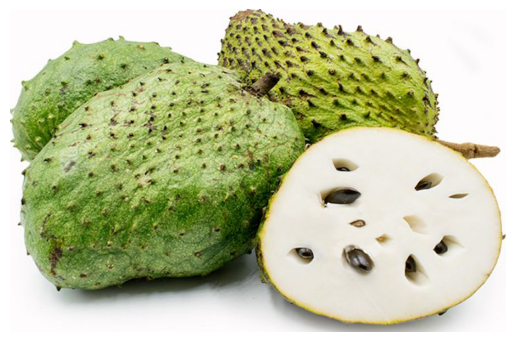

Nama: Kacang mekah polong segar


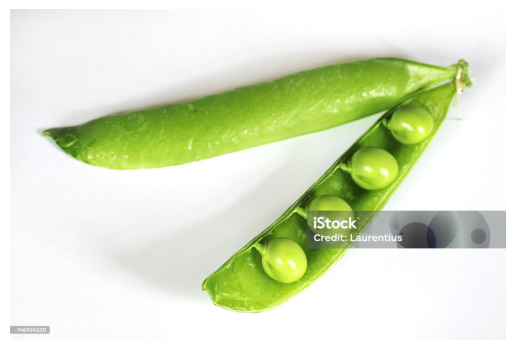

Nama: Brongkos


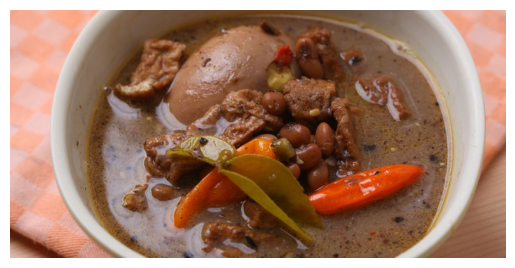

Nama: Kelapa Muda daging


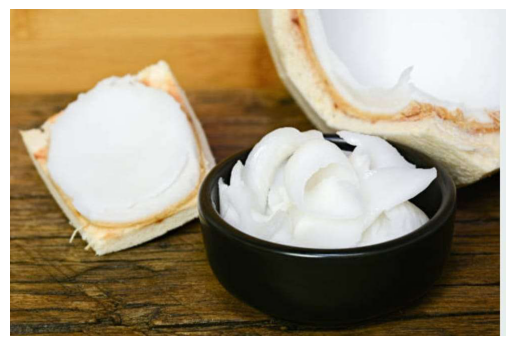

Nama: Mangga Gedong


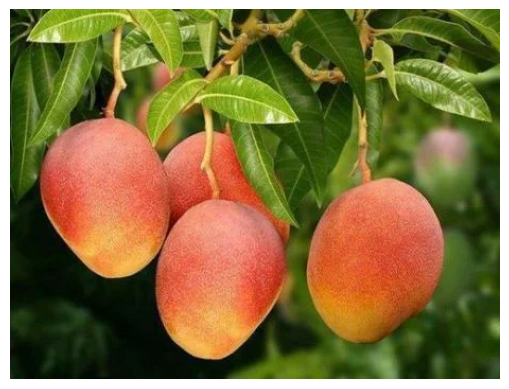

In [39]:
# Menampilkan sample untuk cek
valid_df = df_clean[df_clean['Gambar'].notna()]

samples = valid_df.sample(5)

for _, row in samples.iterrows():
    try:
        print("Nama:", row['Nama'])
        img = Image.open(row['Gambar'])
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except:
        continue

In [40]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103 entries, 2 to 1345
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Kalori                1103 non-null   float64 
 1   Protein               1103 non-null   float64 
 2   Lemak                 1103 non-null   float64 
 3   Karbohidrat           1103 non-null   float64 
 4   Nama                  1103 non-null   string  
 5   URL Gambar            1103 non-null   string  
 6   Total Nutrisi         1103 non-null   float64 
 7   Kategori Kalori       1103 non-null   category
 8   Rasio Protein/Kalori  1103 non-null   float64 
 9   Gambar                1075 non-null   object  
dtypes: category(1), float64(6), object(1), string(2)
memory usage: 87.4+ KB


In [41]:
df_clean.head()

,Kalori,Protein,Lemak,Karbohidrat,Nama,URL Gambar,Total Nutrisi,Kategori Kalori,Rasio Protein/Kalori,Gambar
2,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0.2,Rendah,0.000000,gambar_makanan\agar_agar.jpg
3,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,12.3,Rendah,0.024444,gambar_makanan\akar_tonjong_segar.jpg
4,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,8.7,Rendah,0.118919,gambar_makanan\aletoge_segar.jpg
5,85.0,0.9,6.5,7.7,Alpukat segar,https://katakabar.com/assets/images/upload/new...,15.1,Rendah,0.010588,None
6,96.0,3.7,0.6,19.1,Ampas kacang hijau,https://images.tokopedia.net/img/cache/215-squ...,23.4,Rendah,0.038542,gambar_makanan\ampas_kacang_hijau.jpg


In [43]:
df_clean[df_clean['Gambar'].isna()][['Nama']].head(20)

,Nama
5,Alpukat segar
14,Andewi
28,Asinan Bogor sayuran
66,Baligo
100,Belutlaut segar
172,Buah tuppa segar
210,Chikiniku masakan
242,Daun gunda bali segar
243,Daun gunda serang segar
246,Daun jawaw seluang segar


**Insight:**
- Dataset berhasil digabungkan dengan data gambar makanan. 
- Sebagian besar data memiliki gambar yang valid.
- Hanya sebagian kecil data yang belum mendapatkan gambar.
- Kolom numerik sudah bersih tanpa missing values.

In [42]:
# Menyimpan dataset final ke csv

df_clean.to_csv(
    'data_processed/data_capstone_final.csv',
    index=False
)